# Kalshi Market Time Series Construction
Process all markets & trades parquet files to build bid-ask spread and last price time series.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fastparquet


REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
PATH = REPO_ROOT / "data" / "kalshi"
MARKETS_DIR = PATH / "markets"
TRADES_DIR = PATH / "trades"
OUTPUT_DIR = PATH / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

market_files = sorted(MARKETS_DIR.glob("*.parquet"))
trade_files = sorted(TRADES_DIR.glob("*.parquet"))
print(f"Market files: {len(market_files)}, Trade files: {len(trade_files)}")

Market files: 769, Trade files: 7214


## Process Markets — extract bid/ask/spread/last_price per ticker over time
We process in chunks to avoid OOM, keeping only the columns we need.

In [ ]:
MARKET_COLS = ["ticker", "yes_bid", "yes_ask", "no_bid", "no_ask", "last_price", "open_time", "close_time", "status", "volume"]

chunks = []
for i, f in enumerate(market_files):
    trade_ts = pd.read_parquet(f, columns=MARKET_COLS)
    chunks.append(trade_ts)
    if (i + 1) % 100 == 0:
        print(f"  loaded {i+1}/{len(market_files)} market files")

markets = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Total market rows: {len(markets):,}")
markets.head()

  loaded 100/769 market files
  loaded 200/769 market files
  loaded 300/769 market files
  loaded 400/769 market files
  loaded 500/769 market files
  loaded 600/769 market files
  loaded 700/769 market files
Total market rows: 7,682,445


,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0


In [3]:
# Compute spreads
markets["yes_spread"] = markets["yes_ask"] - markets["yes_bid"]
markets["no_spread"] = markets["no_ask"] - markets["no_bid"]

# Parse times
markets["open_time"] = pd.to_datetime(markets["open_time"], utc=True)
markets["close_time"] = pd.to_datetime(markets["close_time"], utc=True)

markets.head()

,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume,yes_spread,no_spread
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0,0,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0,0,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0,0,0


In [4]:
# Save full processed markets table
markets.to_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"), index=False)
print("Saved all_markets.parquet")

Saved all_markets.parquet


# Check that yes and no prices are consistent

In [2]:
check = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

check.head()


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [8]:
check["arb"] = (check["yes_price"] + check["no_price"] != 100).astype(int)
count_arb = check["arb"].sum()/len(check)*100
print(f"Number of arbitrage trades: {count_arb}")


arb_df = check[check["arb"] == 1]

arb_df.head()

Number of arbitrage trades: 0.3705440628115654


,ticker,yes_price,no_price,count,taker_side,created_time,arb
43563860,KXMVENFLSINGLEGAME-20254463FD1612A-16371CBD9FC,0,99,200,yes,2025-10-09 15:28:03.087254+00:00,1
43564049,KXMVENFLSINGLEGAME-2025BD87D5E46B5-91E6C41D5DE,3,96,249,yes,2025-10-09 15:28:49.067634+00:00,1
43564138,KXMVENFLSINGLEGAME-2025BD87D5E46B5-C3458DB16DF,2,97,446,yes,2025-10-09 15:29:16.099825+00:00,1
43564410,KXMVENFLSINGLEGAME-2025BD87D5E46B5-2CEEF6F8468,1,98,456,yes,2025-10-09 15:30:33.070604+00:00,1
43564670,KXMVENFLSINGLEGAME-202585F482F88EE-5CE6BD56FDD,4,95,20,yes,2025-10-09 15:31:28.075791+00:00,1


In [10]:
arb_df["arb_amount"] = 100 - (arb_df["yes_price"] + arb_df["no_price"])
arb_df["arb_amount"].describe()

C:\Users\ablan\AppData\Local\Temp\ipykernel_13616\2205500781.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arb_df["arb_amount"] = 100 - (arb_df["yes_price"] + arb_df["no_price"])


count    267291.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: arb_amount, dtype: float64

Given that all the inconsistencies are 1.0, its probably due to rounding errors; Note that the actual Kalshi prices can be decimal points when nearing ends

- so can remove no price as it is a linear combination of yes price

In [10]:
# remove no_price from trades to save space
trades.drop(columns=["no_price"], inplace=True)
trades.head()

,ticker,yes_price,count,taker_side,created_time,volume
0,HOME-21JUN-T750,76,5,yes,2021-06-30 20:09:14.185137+00:00,3.8
1,HOME-21JUN-T750,76,10,yes,2021-07-01 14:53:12.675773+00:00,7.6
2,CPI-21JUN-T0.6,17,100,yes,2021-07-01 14:53:38.613666+00:00,17.0
3,GDP-21JUN30-T6.0,81,20,yes,2021-07-01 14:54:00.422415+00:00,16.2
4,TRDDEFCN-21MAY-T30,34,100,yes,2021-07-01 14:54:11.235167+00:00,34.0


# Quick summary stats & sanity checks

In [3]:
# Load processed data
markets = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"))
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

trades.head()


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [4]:
print("\n=== Trades ===")
print(f"Unique tickers traded: {trades['ticker'].nunique():,}")
print(f"Date range: {trades['created_time'].min()} -> {trades['created_time'].max()}")
print(f"Total number of trades: {len(trades):,}")
print(f"Yes price stats:")
print(trades["yes_price"].describe())


=== Trades ===
Unique tickers traded: 586,025
Date range: 2021-06-30 20:09:14.185137+00:00 -> 2025-11-25 22:00:15.194245+00:00
Total number of trades: 72,134,741
Yes price stats:
count    7.213474e+07
mean     4.400762e+01
std      2.779086e+01
min      0.000000e+00
25%      2.000000e+01
50%      4.300000e+01
75%      6.500000e+01
max      9.900000e+01
Name: yes_price, dtype: float64


Most traded ticker: PRES-2024-DJT


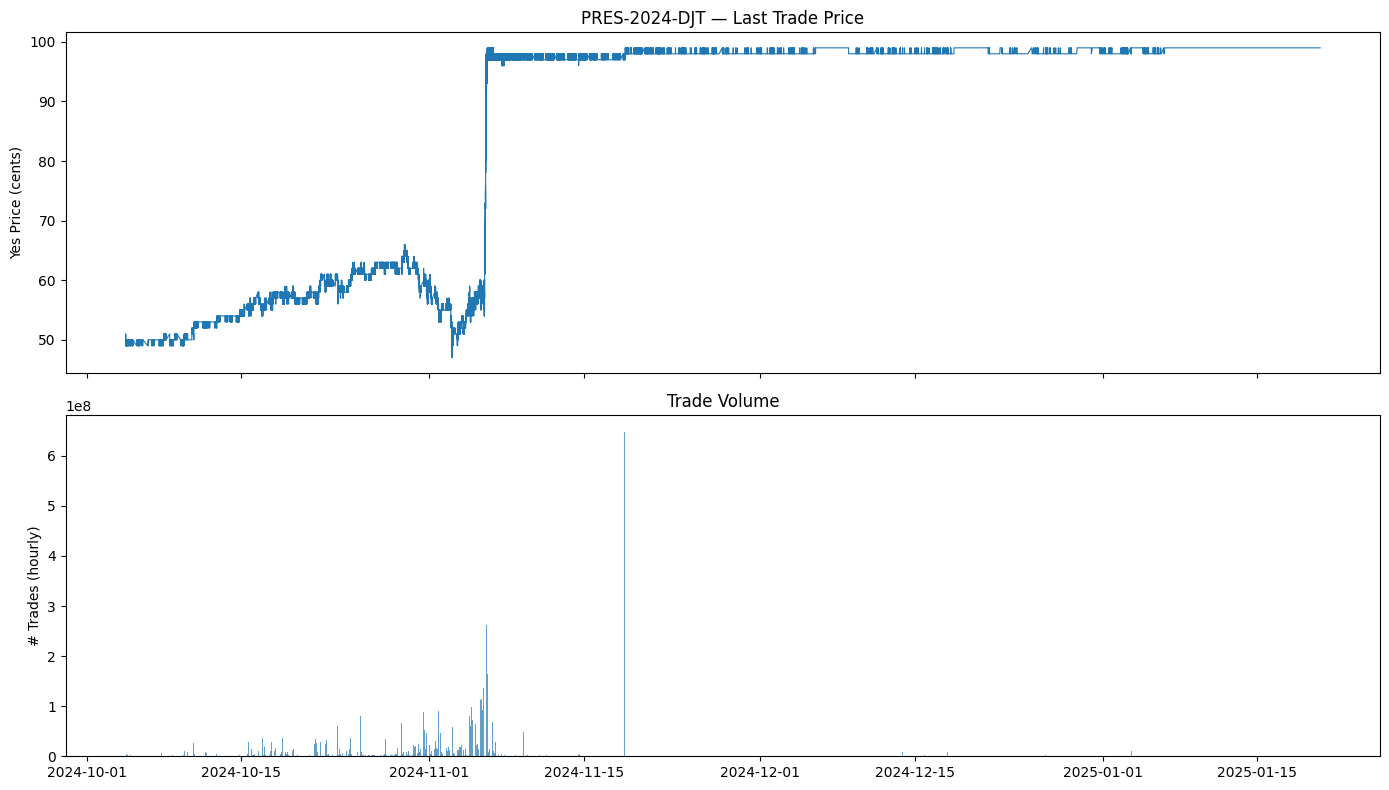

In [5]:
top_ticker = trades.groupby("ticker").size().idxmax()
print(f"Most traded ticker: {top_ticker}")

ts = trades[trades["ticker"] == top_ticker].set_index("created_time").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts["yes_price"], lw=0.8)
axes[0].set_ylabel("Yes Price (cents)")
axes[0].set_title(f"{top_ticker} — Last Trade Price")

# Resample volume to hourly so bar chart has far fewer bars
volume = np.where(ts["taker_side"] == "yes", 
                  ts["count"] * ts["yes_price"], 
                  ts["count"] * ts["no_price"])

volume = pd.Series(volume, index=ts.index).resample("1h").sum()

axes[1].bar(volume.index, volume.values, width=0.03, alpha=0.7)
axes[1].set_ylabel("# Trades (hourly)")
axes[1].set_title("Trade Volume")

plt.tight_layout()
plt.show()



In [6]:
# add volume as a feature
trades["volume"] = np.where(trades["taker_side"] == "yes", 
                            trades["count"] * trades["yes_price"],
                            trades["count"] * (100-trades["yes_price"]))/100 # convert to dollars
trades.head()

,ticker,yes_price,no_price,count,taker_side,created_time,volume
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00,3.8
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00,7.6
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00,17.0
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00,16.2
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00,34.0


### Liquidity metrics

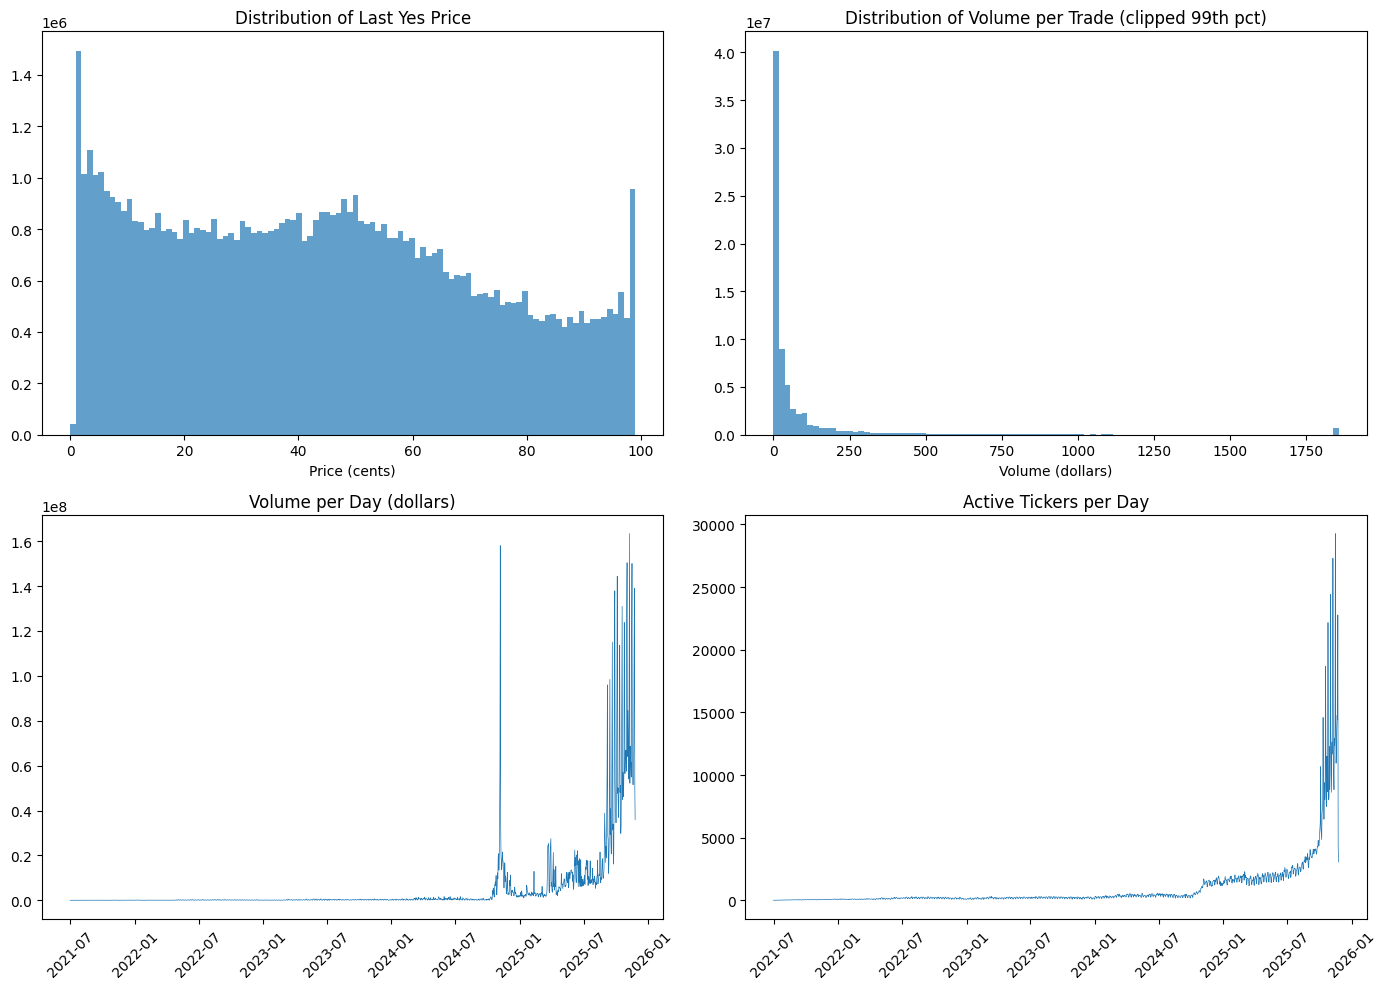

In [7]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Filtering poor contracts
### Do not want poor data from illiquid contracts 
- At first wanted to filter by number of a contract
    - However this introduces lookahead bias
- Decided to cut by timestamp, since Kalshi was not heavily used before a certain point


In [8]:
# Find the first day with > 10M daily volume
daily_volume = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
first_10m = daily_volume[daily_volume > 10000000].index[0]
print(f"First day with > 10M volume: {first_10m}")
original_rows = len(trades)
# Fix: convert date -> UTC-aware Timestamp for comparison
first_10m_ts = pd.Timestamp(first_10m, tz='UTC')


# Remove all trades before this date as well
original_rows = len(trades)
trades = trades[trades["created_time"] >= first_10m_ts].reset_index(drop=True)
print(f"Rows after removing early trades: {original_rows:,} -> {len(trades):,} rows")

First day with > 10M volume: 2024-10-25
Rows after removing early trades: 72,134,741 -> 67,733,505 rows


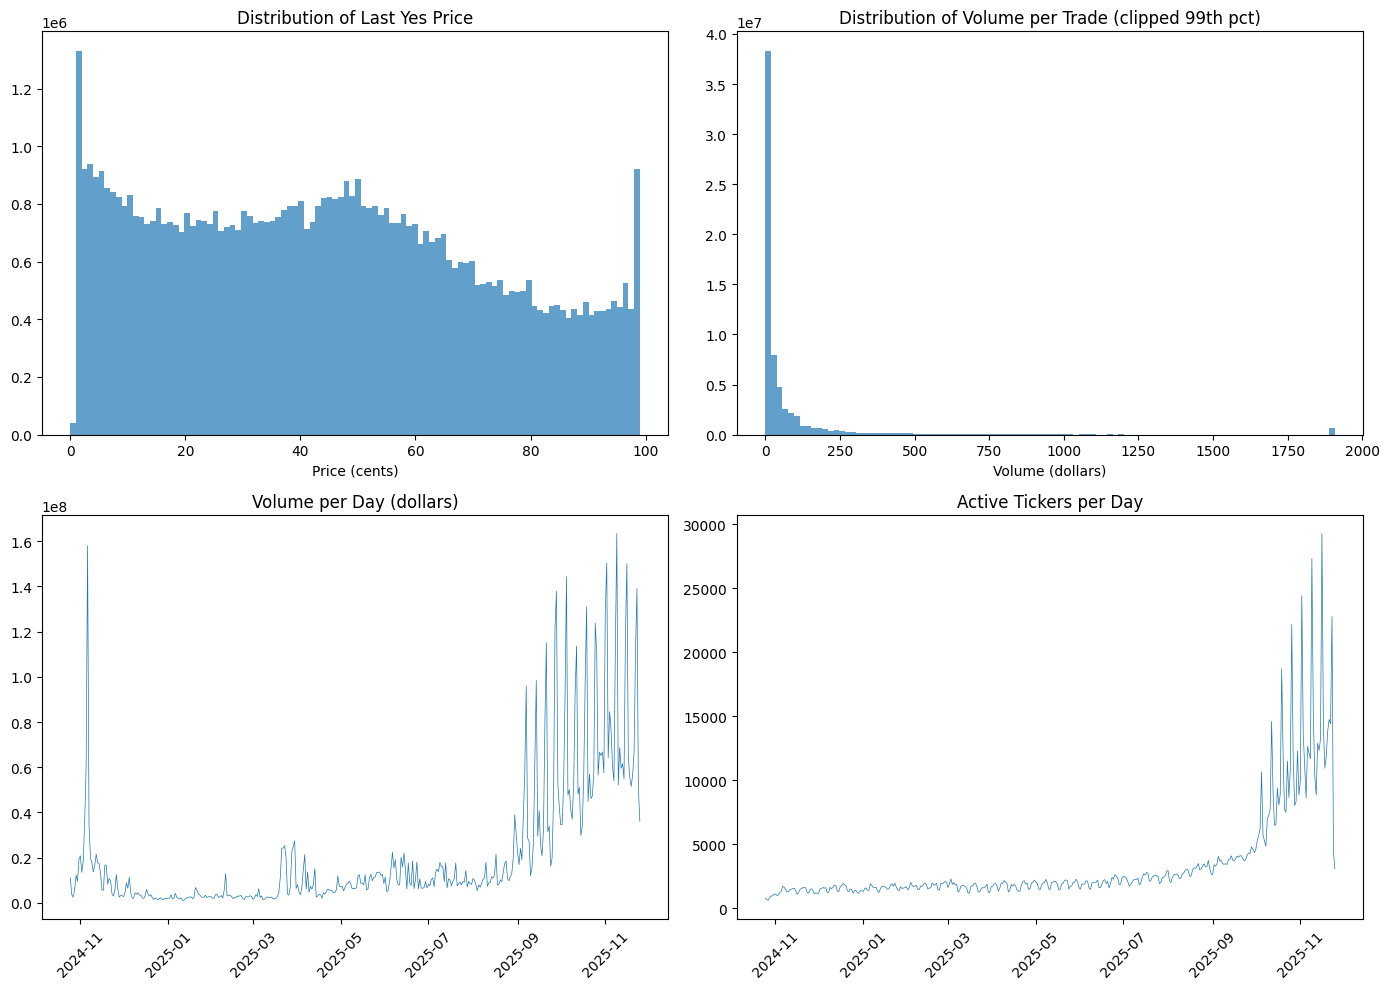

In [9]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Misc

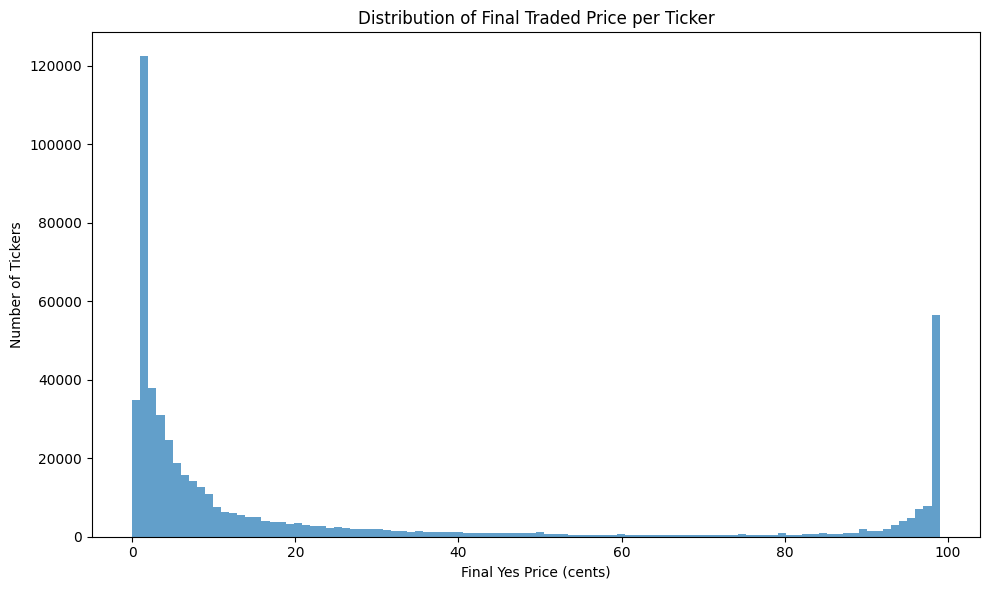

count    533794.000000
mean         25.184732
std          36.228752
min           0.000000
25%           1.000000
50%           5.000000
75%          31.000000
max          99.000000
Name: yes_price, dtype: float64

Tickers ending 0-5 cents:   269,628
Tickers ending 95-100 cents: 80,261
Tickers in between:          183,905


In [10]:
last_price_per_ticker = (
    trades.sort_values("created_time")
            .groupby("ticker")[("yes_price")]
            .last()
)

plt.figure(figsize=(10, 6))
plt.hist(last_price_per_ticker, bins=100, edgecolor="none", alpha=0.7)
plt.title("Distribution of Final Traded Price per Ticker")
plt.xlabel("Final Yes Price (cents)")
plt.ylabel("Number of Tickers")
plt.tight_layout()
plt.show()

print(last_price_per_ticker.describe())
print(f"\nTickers ending 0-5 cents:   {(last_price_per_ticker <= 5).sum():,}")
print(f"Tickers ending 95-100 cents: {(last_price_per_ticker >= 95).sum():,}")
print(f"Tickers in between:          {((last_price_per_ticker > 5) & (last_price_per_ticker < 95)).sum():,}")

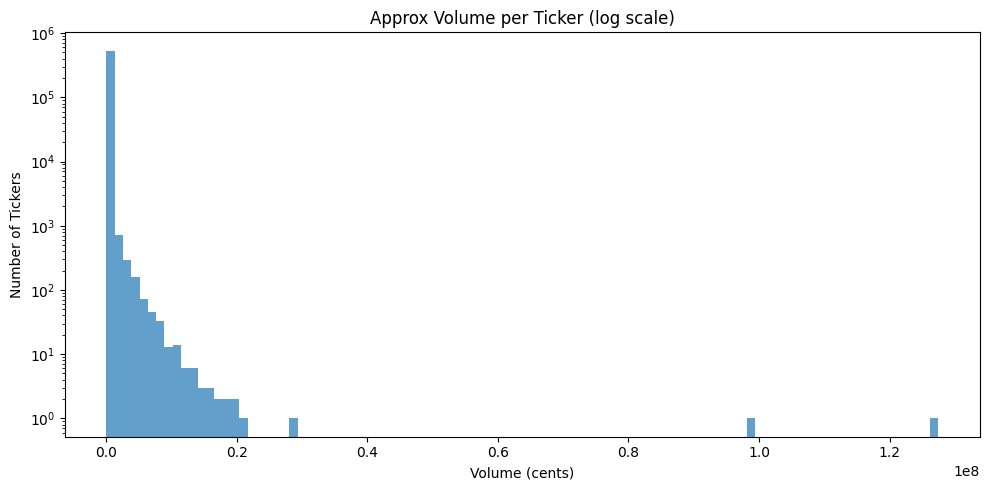

count    5.337940e+05
mean     1.551193e+04
std      3.116735e+05
min      0.000000e+00
25%      1.111000e+01
50%      1.122400e+02
75%      1.398697e+03
max      1.274906e+08
Name: volume, dtype: float64


In [11]:
vol_per_ticker = trades.groupby("ticker")["volume"].sum()

fig, ax = plt.subplots(figsize=(10, 5))  # just 1 subplot

ax.hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7, log=True)
ax.set_title("Approx Volume per Ticker (log scale)")
ax.set_xlabel("Volume (cents)")
ax.set_ylabel("Number of Tickers")

plt.tight_layout()
plt.show()

print(vol_per_ticker.describe())

## How do we classify a large jump?

There are many ways we have found to defined a target
- Continous: Predict direction and magnitude of jumps
- Binary Classification: Predict whether a shock will happen (1) or not (0)
- Multiclass Classification: Predict whether a shock will occur upwards (1), downwards (-1), or not occur (0)

In [12]:
# Sort by time only (not ticker first)
trades = trades.sort_values('created_time').reset_index(drop=True)

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = (
    (merged['yes_price'] - merged['yes_price_15m_ago'])
    / merged['yes_price_15m_ago']
)

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min
0,KXBTC-24OCT2517-B68000,21,79,9,yes,2024-10-25 00:00:09.231249+00:00,1.89,NaN,NaN
1,PRESPARTYWI-24-D,47,53,3498,no,2024-10-25 00:00:19.175932+00:00,1853.94,NaN,NaN
2,PRESPARTYWI-24-D,47,53,2,no,2024-10-25 00:00:19.175932+00:00,1.06,NaN,NaN
3,PRES-2024-KH,40,60,5,yes,2024-10-25 00:00:24.763388+00:00,2.00,NaN,NaN
4,POPVOTE-24-R,35,65,28,yes,2024-10-25 00:00:34.071792+00:00,9.80,NaN,NaN


Non-null 15min returns: 65,603,320


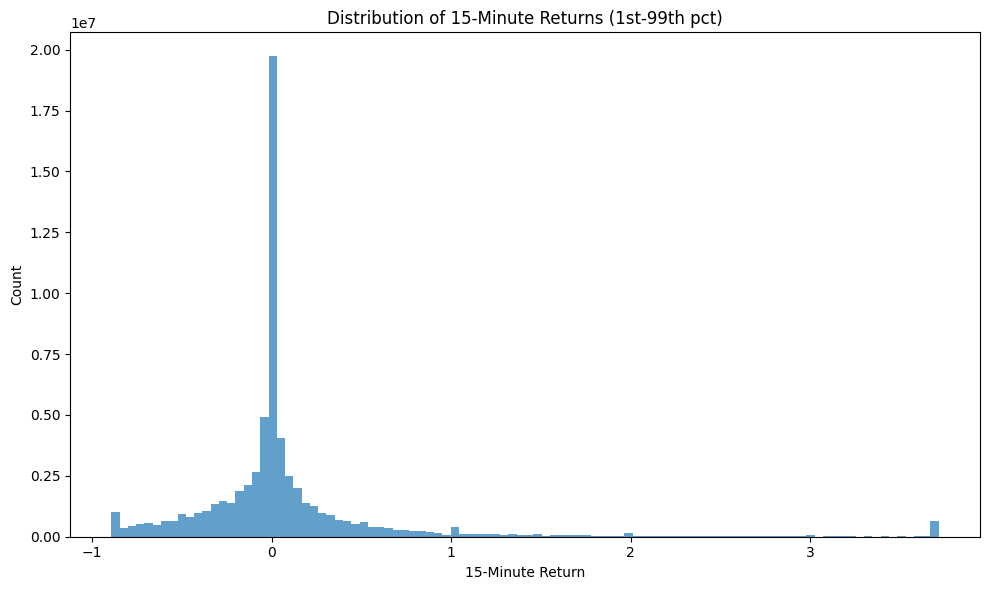

count    6.560264e+07
mean     1.396614e-01
std      1.608253e+00
min     -1.000000e+00
25%     -1.132075e-01
50%      0.000000e+00
75%      9.523810e-02
max      9.800000e+01
Name: return_15min, dtype: float64

Inf values removed: 678
Zero base prices:   6,153


In [15]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [16]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

Kurtosis: 1147.66
Skewness: 27.69


what happens if we take away all the trades that are close to the edge cases?
i.e. price is 0-0.05 and 0.95-1

Rows after removing small base prices: 67,733,505 -> 64,041,575


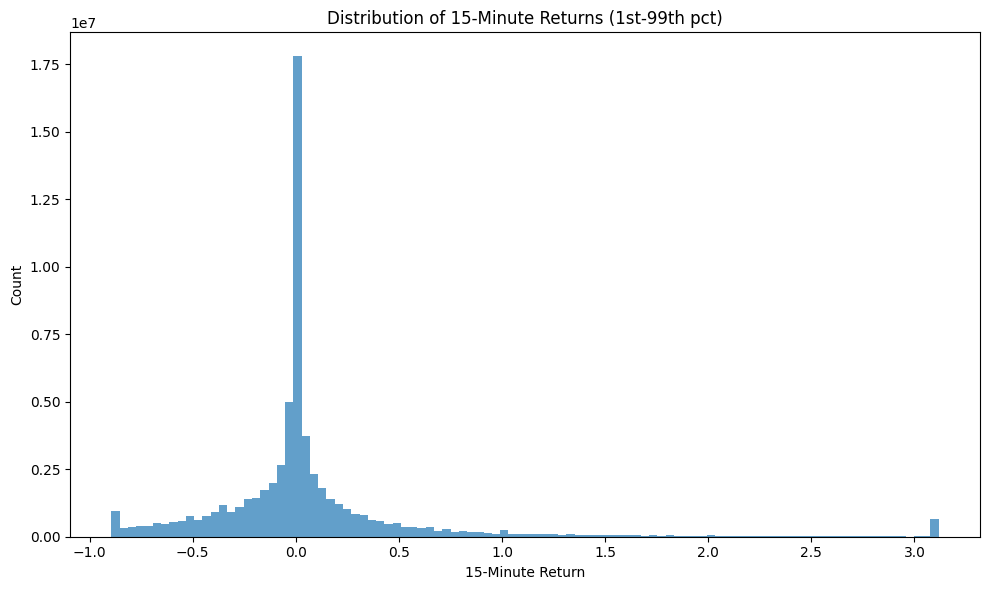

count    6.404158e+07
mean     8.973848e-02
std      8.806224e-01
min     -1.000000e+00
25%     -1.186441e-01
50%      0.000000e+00
75%      9.210526e-02
max      3.200000e+01
Name: return_15min, dtype: float64

Inf values removed: 0
Zero base prices:   0


In [17]:
OG = len(trades)
mask = trades["yes_price_15m_ago"] >= 3
trades = trades.loc[mask].reset_index(drop=True)
del mask
print(f"Rows after removing small base prices: {OG:,} -> {len(trades):,}")

returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)  # use returns_clipped or returns
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [18]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

Kurtosis: 247.98
Skewness: 11.78


## Absolute returns

In [20]:
trades = trades.sort_values('created_time').reset_index(drop=True)

# Drop stale column if it exists from a previous run
trades = trades.drop(columns=['yes_price_15m_ago', 'return_15min'], errors='ignore')

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = merged['yes_price'] - merged['yes_price_15m_ago']

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min
0,PRES-2024-KH,39,61,250,yes,2024-10-25 00:15:29.430123+00:00,97.50,NaN,NaN
1,PRES-2024-KH,39,61,128,yes,2024-10-25 00:15:42.873031+00:00,49.92,NaN,NaN
2,POPVOTE-24-R,36,64,27,yes,2024-10-25 00:15:44.600354+00:00,9.72,NaN,NaN
3,PRES-2024-KH,39,61,38,yes,2024-10-25 00:15:57.151717+00:00,14.82,NaN,NaN
4,POPVOTE-24-R,35,65,20,no,2024-10-25 00:16:18.724459+00:00,13.00,NaN,NaN


Non-null 15min returns: 62,256,896


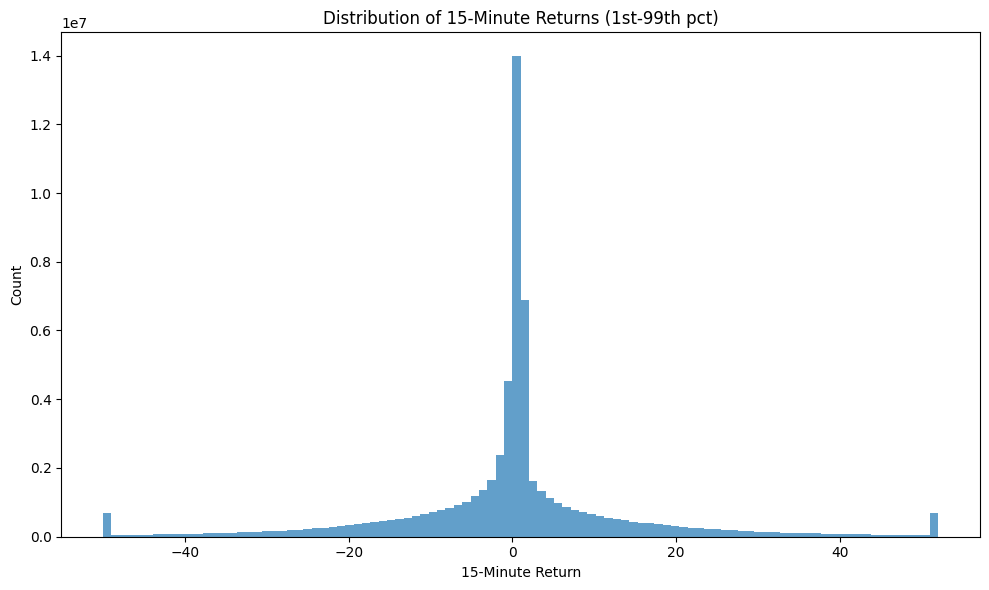

count    6.225690e+07
mean    -8.632912e-02
std      1.591045e+01
min     -9.800000e+01
25%     -4.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      9.800000e+01
Name: return_15min, dtype: float64

Inf values removed: 0
Zero base prices:   1


In [21]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [22]:
print("Kurtosis: {:.2f}".format(returns.kurtosis()))
print("Skewness: {:.2f}".format(returns.skew()))

Kurtosis: 5.80
Skewness: 0.12


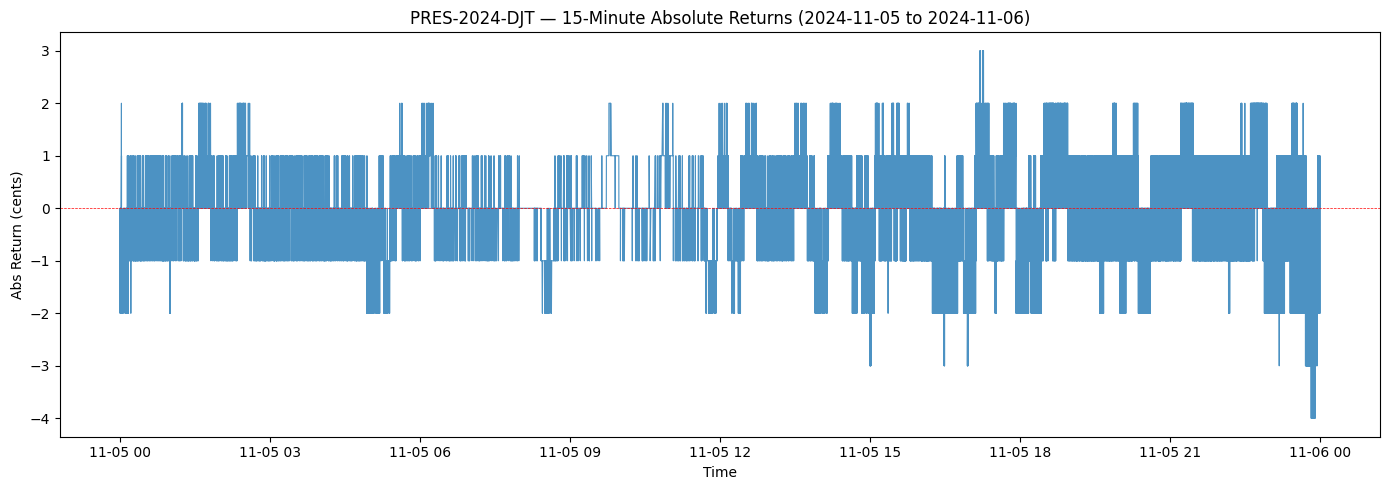

count    58938.000000
mean        -0.047134
std          0.785525
min         -4.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: return_15min, dtype: float64


In [32]:
start_date = pd.Timestamp('2024-11-05', tz='UTC')
end_date   = pd.Timestamp('2024-11-06', tz='UTC')

djt = (
    trades[
        (trades["ticker"] == "PRES-2024-DJT") &
        (trades["created_time"] >= start_date) &
        (trades["created_time"] <= end_date)
    ]
    .sort_values("created_time")
)

plt.figure(figsize=(14, 5))
plt.plot(djt["created_time"], djt["return_15min"], lw=0.8, alpha=0.8)
plt.axhline(0, color="red", lw=0.5, linestyle="--")
plt.title(f"PRES-2024-DJT — 15-Minute Absolute Returns ({start_date.date()} to {end_date.date()})")
plt.xlabel("Time")
plt.ylabel("Abs Return (cents)")
plt.tight_layout()
plt.show()

print(djt["return_15min"].describe())